# Project Notebook v2 — Part 3: Model Training & Evaluation

Model comparison, hyperparameter search, and final evaluation split out of `project_notebook_v2.ipynb`. Requires the artifacts written by **Part 1 (data prep)** — run that notebook first.

In [18]:
# --- Load prepared data (run project_notebook_v2_data_prep.ipynb first) ---
import json

import numpy as np
import pandas as pd

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

df = pd.read_pickle('artifacts/df_clean.pkl')       # cleaned full dataset
cohort = pd.read_pickle('artifacts/cohort.pkl')     # modelling cohort (with target)
data = pd.read_pickle('artifacts/data.pkl')         # modelling frame (features + target + died)
with open('artifacts/feature_lists.json') as f:
    _fl = json.load(f)
numeric_features = _fl['numeric_features']
binary_features = _fl['binary_features']
categorical_features = _fl['categorical_features']
comorbidity_cols = _fl['comorbidity_cols']
feature_cols = _fl['feature_cols']

X = data[feature_cols]
y = data['target']
print(f"Loaded: df {df.shape} | cohort {cohort.shape} | data {data.shape} | X {X.shape}")

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# Age bands (defined with the EDA in Part 2; also needed here for the error analysis)
age_bins = [0, 18, 30, 40, 50, 60, 70, 80, 120]
age_labels = ['0-17', '18-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+']

Loaded: df (263007, 42) | cohort (263007, 43) | data (260933, 23) | X (260933, 21)


# Section B — Model Comparison

We compare three genuinely different families against a trivial reference, all sharing the same leakage-safe preprocessing and evaluated with 5-fold stratified CV on the **training set only**:

- **Dummy (prior)** — trivial baseline that always predicts the majority class / base rate.
- **Logistic Regression** — simple, interpretable linear model.
- **Random Forest** — bagged nonlinear trees.
- **Neural Network (MLP)** — multi-layer perceptron on the scaled / one-hot encoded features.

**Primary metric: ROC-AUC** (threshold-independent and robust to the class imbalance), reported alongside PR-AUC, F1 and recall so we can see behaviour at the default threshold.

**Pre-experiment expectation.** I expect the **MLP to win**: admission is driven mainly by age and comorbidity burden with likely nonlinearities and interactions (e.g. age × diabetes), which a neural network can capture once the inputs are scaled and one-hot encoded. I expect **logistic regression to be a close second** because much of the age/comorbidity effect is roughly monotone, **random forest in between**, and all three well above the dummy.

### Train/test split (created before any model selection)

We use a **stratified random 80/20 split** with a fixed seed. A random split is appropriate here because each row is already a distinct patient — the `registry_id` count equals the number of rows (checked above) — so there is no repeated-patient leakage across folds; and we are not claiming temporal extrapolation, which would instead call for an earlier-vs-later split. The test indices are saved to disk immediately and are not touched again during EDA, model comparison, or hyperparameter search — only in the final evaluation.

In [19]:
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    data.index.to_numpy(),
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

# Persist the split BEFORE any model selection (reproducibility checklist)
np.save('train_idx.npy', train_idx)
np.save('test_idx.npy', test_idx)

X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]
train_data = data.loc[train_idx]   # training-set frame used for EDA

print(f"Train: {len(train_idx):,}  |  Test: {len(test_idx):,}")
print(f"Train prevalence: {y_train.mean():.3f}  |  Test prevalence: {y_test.mean():.3f}")

Train: 208,746  |  Test: 52,187
Train prevalence: 0.234  |  Test prevalence: 0.234


In [20]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def make_preprocessor():
    """Preprocessing shared by every model. No imputation — missingness was handled during
    feature cleaning (rows dropped, set to No, or given an explicit 'Unknown' category)."""
    return ColumnTransformer([
        ('num', StandardScaler(), numeric_features),
        ('bin', 'passthrough', binary_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ])

In [21]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_validate

scoring = ['roc_auc', 'average_precision', 'f1', 'recall']

models = {
    'Dummy (prior)':        DummyClassifier(strategy='prior'),
    'Logistic Regression':  LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest':        RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                                   random_state=RANDOM_STATE),
    'Neural Network (MLP)': MLPClassifier(hidden_layer_sizes=(64,), early_stopping=True,
                                          max_iter=200, random_state=RANDOM_STATE),
}

rows = []
for name, clf in models.items():
    pipe = Pipeline([('prep', make_preprocessor()), ('clf', clf)])
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    rows.append({
        'model':   name,
        'ROC_AUC': res['test_roc_auc'].mean(),
        'PR_AUC':  res['test_average_precision'].mean(),
        'F1':      res['test_f1'].mean(),
        'Recall':  res['test_recall'].mean(),
    })

results = pd.DataFrame(rows).set_index('model').round(3)
results

,ROC_AUC,PR_AUC,F1,Recall
model,,,,
Dummy (prior),0.500,0.234,0.000,0.000
Logistic Regression,0.845,0.648,0.557,0.461
Random Forest,0.858,0.662,0.620,0.587
Neural Network (MLP),0.896,0.743,0.666,0.610


# Section C — Final Pipeline, Cross-Validation & Hyperparameter Search

We wrap **all learned steps** (scaling, one-hot encoding, and the classifier) into a single `Pipeline`, so every preprocessing transform is fit only on the training folds and never sees the test set. (No imputation step is needed — missing values were resolved during feature cleaning.) From Section B we take the **neural network (MLP)** as the final family and tune it with **Optuna** (TPE sampler, seeded for reproducibility) using the same 5-fold stratified CV on the training set, optimising ROC-AUC.

**Search space.** Depth (1–2 hidden layers), width per layer (32–256 units, log scale), L2 penalty `alpha` (1e-6–1e-1, log), initial learning rate (1e-4–1e-2, log), and batch size {128, 256, 512}. Each candidate uses early stopping on an internal 10% validation split, so `max_iter` acts as a cap rather than a tuned parameter.

**Search budget.** Optuna runs **30 trials**; each is scored with 5-fold CV, so **150 fitted models** plus one final refit — under the ~200 budget. Unlike a grid, the TPE sampler adapts: later trials concentrate around the regions that scored well earlier. Below we report the protocol, the trial/fit counts, the best hyperparameters, and the best validation score. The held-out test set is used only in the final evaluation cell.

In [22]:
# import optuna
# from sklearn.model_selection import cross_val_score
# 
# N_TRIALS = 30
# 
# 
# def make_mlp(trial):
#     """Build an MLPClassifier from an Optuna trial (also works with a FixedTrial for the refit)."""
#     n_layers = trial.suggest_int('n_layers', 1, 2)
#     hidden = tuple(trial.suggest_int(f'n_units_l{i}', 32, 256, log=True)
#                    for i in range(n_layers))
#     return MLPClassifier(
#         hidden_layer_sizes=hidden,
#         alpha=trial.suggest_float('alpha', 1e-6, 1e-1, log=True),
#         learning_rate_init=trial.suggest_float('learning_rate_init', 1e-4, 1e-2, log=True),
#         batch_size=trial.suggest_categorical('batch_size', [128, 256, 512]),
#         early_stopping=True, validation_fraction=0.1, n_iter_no_change=10,
#         max_iter=200, random_state=RANDOM_STATE,
#     )
# 
# 
# def objective(trial):
#     pipe = Pipeline([('prep', make_preprocessor()), ('clf', make_mlp(trial))])
#     return cross_val_score(pipe, X_train, y_train, cv=cv,
#                            scoring='roc_auc', n_jobs=-1).mean()
# 
# 
# optuna.logging.set_verbosity(optuna.logging.WARNING)   # keep the notebook output readable
# study = optuna.create_study(
#     direction='maximize',
#     sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
# )
# study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
# 
# print(f"Trials: {len(study.trials)}  |  Total CV fits: {len(study.trials) * cv.get_n_splits()}")
# print(f"\nBest CV ROC-AUC within training on validation: {study.best_value:.4f}")
# print("Best hyperparameters:")
# for k, v in study.best_params.items():
#     print(f"  {k} = {v}")
# 
# # Refit the best configuration on the full training set (what GridSearchCV's refit=True did)
# best_model = Pipeline([
#     ('prep', make_preprocessor()),
#     ('clf', make_mlp(optuna.trial.FixedTrial(study.best_params))),
# ]).fit(X_train, y_train)

In [23]:
# --- DEV SHORTCUT: skip the Optuna search above and train directly with its best result ---
# Best hyperparameters from a previous full run (Trials: 30 | Total CV fits: 150,
# Best CV ROC-AUC within training on validation: 0.8958).
# Run either the Optuna cell above OR this cell -- both produce `best_model`.

best_params = {
    'n_layers': 1,
    'n_units_l0': 176,
    'alpha': 0.0004218279954930134,
    'learning_rate_init': 0.001563469271718208,
    'batch_size': 512,
}

hidden = tuple(best_params[f'n_units_l{i}'] for i in range(best_params['n_layers']))

best_model = Pipeline([
    ('prep', make_preprocessor()),
    ('clf', MLPClassifier(
        hidden_layer_sizes=hidden,
        alpha=best_params['alpha'],
        learning_rate_init=best_params['learning_rate_init'],
        batch_size=best_params['batch_size'],
        early_stopping=True, validation_fraction=0.1, n_iter_no_change=10,
        max_iter=200, random_state=RANDOM_STATE,
    )),
]).fit(X_train, y_train)

print("best_model trained on the full training set with the fixed best hyperparameters.")

best_model trained on the full training set with the fixed best hyperparameters.


## [V3 ADDED] Decision diagnostics — training data only (test set untouched)

Threshold choice and feature importance are **decisions**, so they must not be made on the
held-out test set. The cells below produce **out-of-fold (OOF)** predictions on the training
set with `cross_val_predict`: the pipeline is refit per CV fold, so every training row is
scored by a model that never saw it. All performance numbers, the metric-vs-threshold sweep,
and the permutation importance here use *only* training data — the test set is first touched
in the final evaluation cells further down.

*Note: the OOF cell refits the pipeline once per fold (5 extra fits), so it takes roughly
5x the single training fit above.*

In [32]:
# ===== [V3 ADDED] Pre-test performance check: OOF predictions + threshold-free metrics. =====
# Cross-validated performance of the final model WITHOUT the test set. clone() gives an
# unfitted copy of best_model; cross_val_predict refits it per fold and returns
# out-of-fold probabilities for every training row. Threshold-dependent numbers
# (confusion matrix, F1, ...) follow AFTER the operating threshold is chosen below.
from sklearn.base import clone
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             precision_score, recall_score, balanced_accuracy_score,
                             brier_score_loss, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.calibration import CalibrationDisplay

oof_proba = cross_val_predict(clone(best_model), X_train, y_train,
                              cv=cv, method='predict_proba', n_jobs=-1)[:, 1]

print("=== Cross-validated (out-of-fold) TRAINING performance — test set untouched ===")
print(f"ROC-AUC    : {roc_auc_score(y_train, oof_proba):.3f}")
print(f"PR-AUC     : {average_precision_score(y_train, oof_proba):.3f}")
print(f"Brier score: {brier_score_loss(y_train, oof_proba):.3f}")

=== Cross-validated (out-of-fold) TRAINING performance — test set untouched ===
ROC-AUC    : 0.896
PR-AUC     : 0.745
Brier score: 0.103


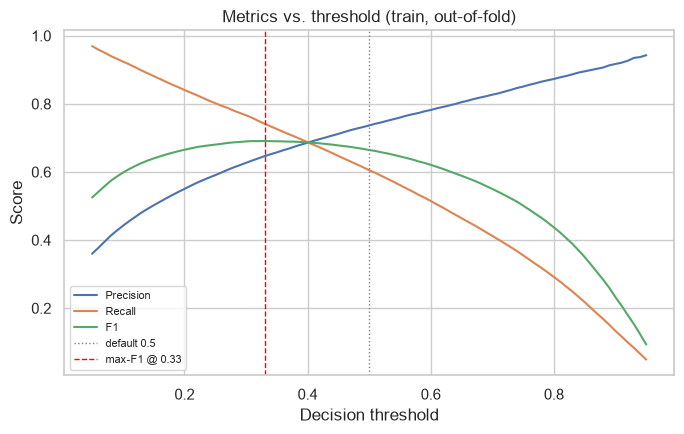

Operating threshold chosen on training OOF data: 0.33  (precision=0.646, recall=0.742, F1=0.691)


In [33]:
# ===== [V3 ADDED] Metrics vs. threshold on OOF TRAINING predictions (decision-safe). =====
# Same sweep as in the test-set evaluation figure below, but on out-of-fold training
# predictions — this is where the operating threshold is actually allowed to be chosen.
thresholds = np.linspace(0.05, 0.95, 91)
prec_t, rec_t, f1_t = [], [], []
for t in thresholds:
    pred_t = (oof_proba >= t).astype(int)
    prec_t.append(precision_score(y_train, pred_t, zero_division=0))
    rec_t.append(recall_score(y_train, pred_t, zero_division=0))
    f1_t.append(f1_score(y_train, pred_t, zero_division=0))
best_t_train = float(thresholds[int(np.argmax(f1_t))])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(thresholds, prec_t, label="Precision")
ax.plot(thresholds, rec_t, label="Recall")
ax.plot(thresholds, f1_t, label="F1")
ax.axvline(0.5, color='grey', ls=':', lw=1, label="default 0.5")
ax.axvline(best_t_train, color='red', ls='--', lw=1, label=f"max-F1 @ {best_t_train:.2f}")
ax.set_xlabel("Decision threshold"); ax.set_ylabel("Score")
ax.set_title("Metrics vs. threshold (train, out-of-fold)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

CHOSEN_THRESHOLD = best_t_train   # decided here, on training data — reuse in the test evaluation
pred_bt = (oof_proba >= best_t_train).astype(int)
print(f"Operating threshold chosen on training OOF data: {CHOSEN_THRESHOLD:.2f}  "
      f"(precision={precision_score(y_train, pred_bt, zero_division=0):.3f}, "
      f"recall={recall_score(y_train, pred_bt, zero_division=0):.3f}, "
      f"F1={f1_score(y_train, pred_bt, zero_division=0):.3f})")

In [34]:
# ===== [V3 ADDED] Final model = best_model + the training-chosen operating threshold. =====
# FixedThresholdClassifier wraps the pipeline so .predict() applies CHOSEN_THRESHOLD
# instead of the default 0.5; .predict_proba() is passed through unchanged.
# FrozenEstimator marks best_model as already fitted, so .fit() below refits nothing.
# Everything below (test evaluation, error analysis) uses final_model.
from sklearn.frozen import FrozenEstimator
from sklearn.model_selection import FixedThresholdClassifier

final_model = FixedThresholdClassifier(
    FrozenEstimator(best_model), threshold=CHOSEN_THRESHOLD,
).fit(X_train, y_train)

print(f"final_model = best_model operating at threshold {CHOSEN_THRESHOLD:.2f} "
      f"(chosen on training OOF data, not on the test set)")

final_model = best_model operating at threshold 0.33 (chosen on training OOF data, not on the test set)


=== OOF training performance: chosen threshold 0.33 vs. default 0.50 ===
                      @ 0.33    @ 0.50
F1                     0.691     0.664
Precision              0.646     0.737
Recall                 0.742     0.605
Balanced accuracy      0.809     0.769


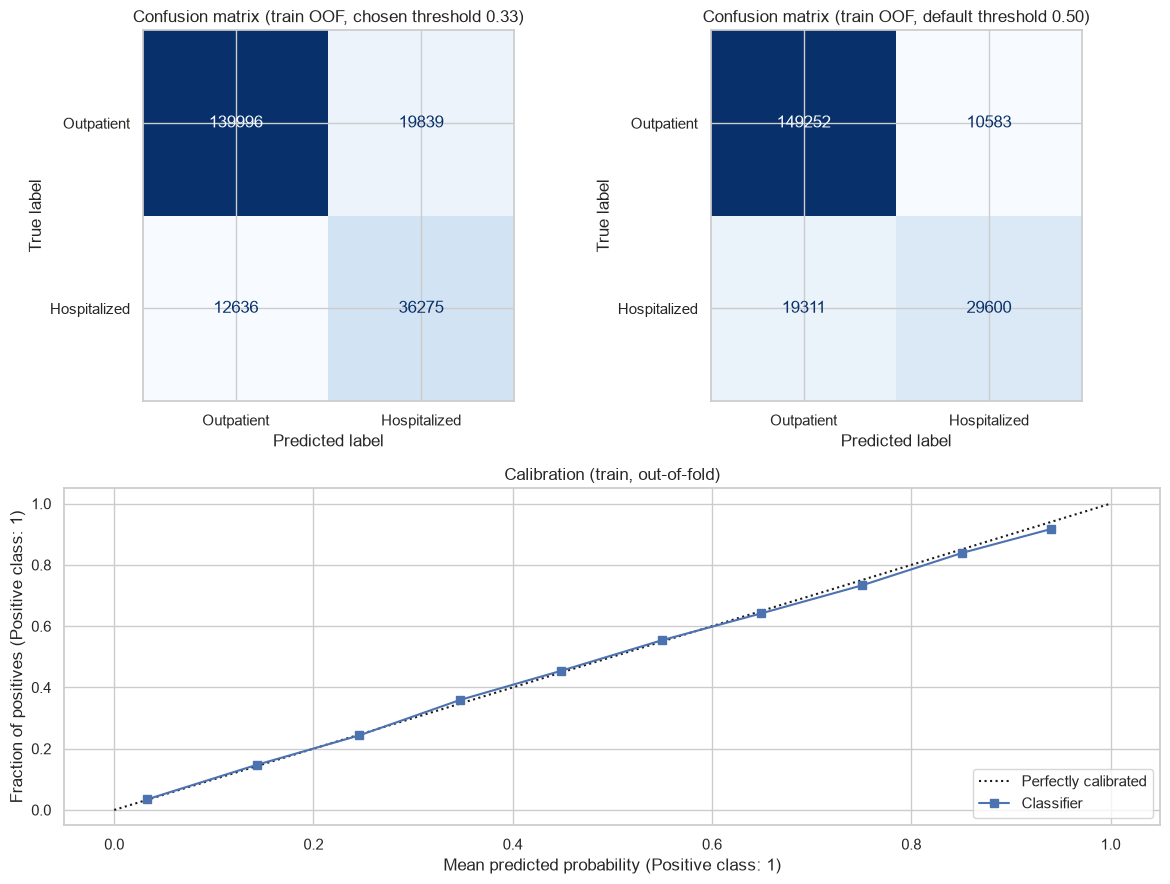

In [36]:
# ===== [V3 ADDED] OOF confusion matrices (chosen vs. default threshold) + calibration. =====
# Left: the operating point chosen on training data. Right: the default 0.5 cutoff,
# for comparison only. Below: calibration (threshold-free). All on OOF training
# predictions — the test set is still untouched.
oof_pred = (oof_proba >= CHOSEN_THRESHOLD).astype(int)
oof_pred_05 = (oof_proba >= 0.5).astype(int)

print(f"=== OOF training performance: chosen threshold {CHOSEN_THRESHOLD:.2f} vs. default 0.50 ===")
print(f"{'':18s}{'@ ' + format(CHOSEN_THRESHOLD, '.2f'):>10s}{'@ 0.50':>10s}")
print(f"{'F1':18s}{f1_score(y_train, oof_pred):>10.3f}{f1_score(y_train, oof_pred_05):>10.3f}")
print(f"{'Precision':18s}{precision_score(y_train, oof_pred):>10.3f}{precision_score(y_train, oof_pred_05):>10.3f}")
print(f"{'Recall':18s}{recall_score(y_train, oof_pred):>10.3f}{recall_score(y_train, oof_pred_05):>10.3f}")
print(f"{'Balanced accuracy':18s}{balanced_accuracy_score(y_train, oof_pred):>10.3f}{balanced_accuracy_score(y_train, oof_pred_05):>10.3f}")

fig, axes = plt.subplot_mosaic([['cm_chosen', 'cm_05'], ['cal', 'cal']],
                               figsize=(12, 9), height_ratios=[1.1, 1])
ConfusionMatrixDisplay(
    confusion_matrix(y_train, oof_pred),
    display_labels=['Outpatient', 'Hospitalized'],
).plot(ax=axes['cm_chosen'], colorbar=False, cmap='Blues', values_format='d')
axes['cm_chosen'].set_title(f'Confusion matrix (train OOF, chosen threshold {CHOSEN_THRESHOLD:.2f})')
ConfusionMatrixDisplay(
    confusion_matrix(y_train, oof_pred_05),
    display_labels=['Outpatient', 'Hospitalized'],
).plot(ax=axes['cm_05'], colorbar=False, cmap='Blues', values_format='d')
axes['cm_05'].set_title('Confusion matrix (train OOF, default threshold 0.50)')
CalibrationDisplay.from_predictions(y_train, oof_proba, n_bins=10, ax=axes['cal'])
axes['cal'].set_title('Calibration (train, out-of-fold)')
plt.tight_layout(); plt.show()

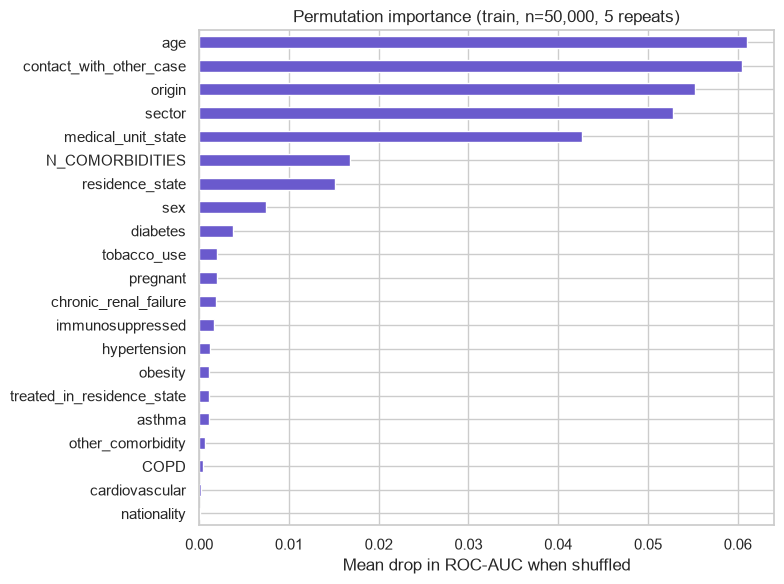

In [38]:
# ===== [V3 ADDED] Permutation importance on TRAINING data (decision-safe). =====
# Same setup as the test-set version below, but shuffling training rows — safe to use
# for feature decisions. Uses best_model as fitted on the full training set; subsampled
# for speed like the test-set variant.
from sklearn.inspection import permutation_importance

rng = np.random.RandomState(RANDOM_STATE)
n_pi = min(50000, len(X_train))
sub = rng.choice(len(X_train), size=n_pi, replace=False)
pi_train = permutation_importance(best_model, X_train.iloc[sub], y_train.iloc[sub],
                                  scoring='roc_auc', n_repeats=5,
                                  random_state=RANDOM_STATE, n_jobs=-1)
imp_train = (pd.Series(pi_train.importances_mean, index=X_train.columns)
             .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(8, 6))
imp_train.plot.barh(ax=ax, color='slateblue')
ax.set_xlabel("Mean drop in ROC-AUC when shuffled")
ax.set_title(f"Permutation importance (train, n={n_pi:,}, 5 repeats)")
plt.tight_layout(); plt.show()

=== Held-out test performance (evaluated once, after model selection) ===
Operating threshold: 0.33 (chosen on training OOF data)
ROC-AUC  : 0.895
PR-AUC   : 0.742
F1       : 0.686
Precision: 0.640
Recall   : 0.739


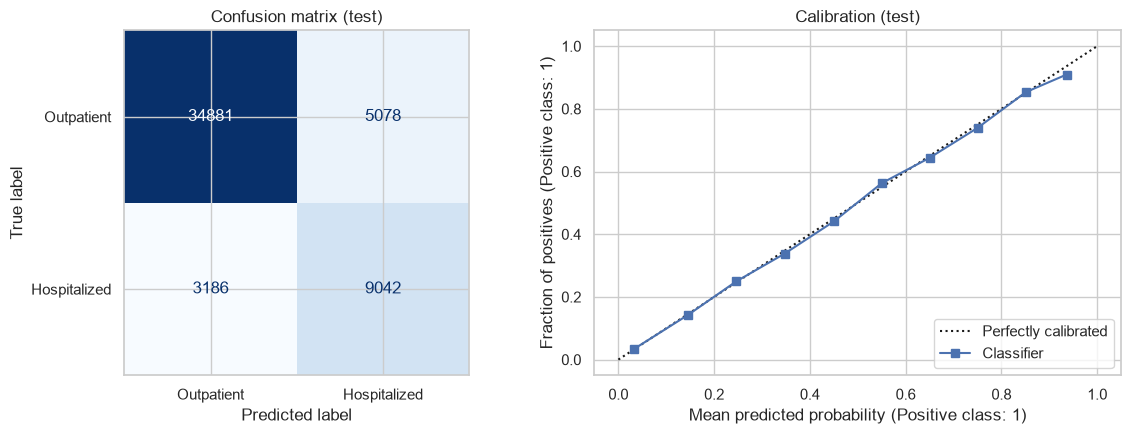

In [31]:
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             recall_score, precision_score, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.calibration import CalibrationDisplay

# final_model = tuned pipeline + operating threshold, both decided on training data only

test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred = final_model.predict(X_test)   # applies CHOSEN_THRESHOLD, not 0.5

print("=== Held-out test performance (evaluated once, after model selection) ===")
print(f"Operating threshold: {CHOSEN_THRESHOLD:.2f} (chosen on training OOF data)")
print(f"ROC-AUC  : {roc_auc_score(y_test, test_proba):.3f}")
print(f"PR-AUC   : {average_precision_score(y_test, test_proba):.3f}")
print(f"F1       : {f1_score(y_test, test_pred):.3f}")
print(f"Precision: {precision_score(y_test, test_pred):.3f}")
print(f"Recall   : {recall_score(y_test, test_pred):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, test_pred),
    display_labels=['Outpatient', 'Hospitalized'],
).plot(ax=axes[0], colorbar=False, cmap='Blues', values_format='d')
axes[0].set_title('Confusion matrix (test)')
CalibrationDisplay.from_predictions(y_test, test_proba, n_bins=10, ax=axes[1])
axes[1].set_title('Calibration (test)')
plt.tight_layout(); plt.show()

## [V2 ADDED] Final-model evaluation plots

Report-ready diagnostics for the tuned final model on the held-out test set: ROC and
precision–recall curves, a threshold sweep (precision / recall / F1 vs. decision threshold),
the predicted-probability distribution by true class, permutation feature importance, and
false-negative rate by age band. These complement the confusion matrix and calibration plot
above and drop straight into the report.

*Note:* the max-F1 threshold marked below is computed on the test set for illustration only;
for an honest operating point, choose the threshold on validation/CV data and apply it once to
the test set.

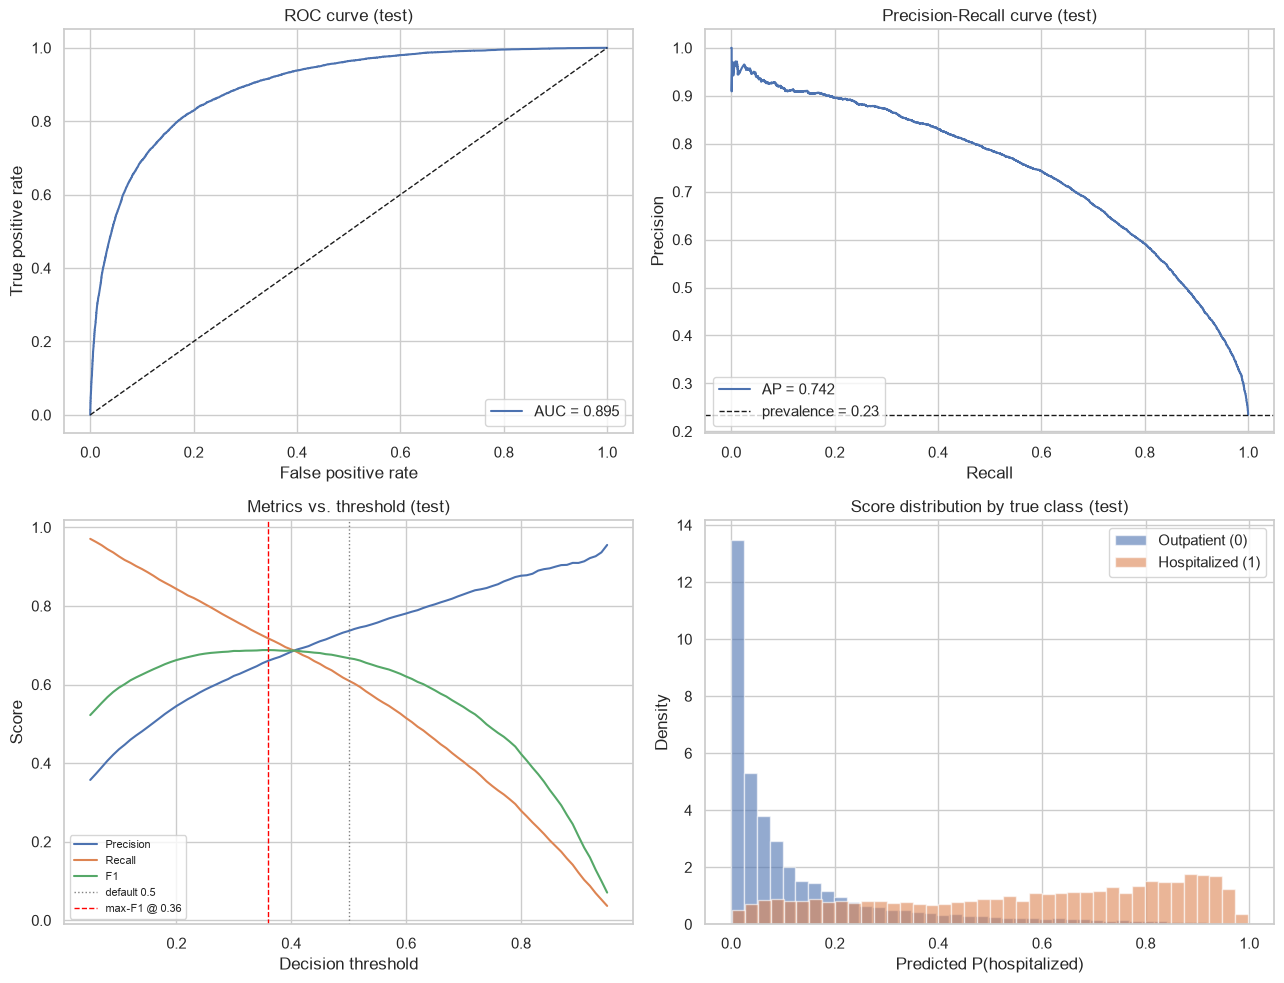

Max-F1 threshold on test = 0.36  (precision=0.660, recall=0.717)
NOTE: pick the operating threshold on validation/CV data, not on the test set, for the report.


In [8]:
# ===== [V2 ADDED] Four-panel evaluation figure for the final model (test set). =====
from sklearn.metrics import (roc_curve, precision_recall_curve, roc_auc_score,
                             average_precision_score, f1_score, precision_score, recall_score)

proba = final_model.predict_proba(X_test)[:, 1]   # same probabilities as best_model

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# (1) ROC curve
fpr, tpr, _ = roc_curve(y_test, proba)
axes[0, 0].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, proba):.3f}")
axes[0, 0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 0].set_xlabel("False positive rate"); axes[0, 0].set_ylabel("True positive rate")
axes[0, 0].set_title("ROC curve (test)"); axes[0, 0].legend(loc="lower right")

# (2) Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_test, proba)
axes[0, 1].plot(rec, prec, label=f"AP = {average_precision_score(y_test, proba):.3f}")
axes[0, 1].axhline(y_test.mean(), color='k', ls='--', lw=1, label=f"prevalence = {y_test.mean():.2f}")
axes[0, 1].set_xlabel("Recall"); axes[0, 1].set_ylabel("Precision")
axes[0, 1].set_title("Precision-Recall curve (test)"); axes[0, 1].legend(loc="lower left")

# (3) Threshold sweep: precision / recall / F1 vs decision threshold
thresholds = np.linspace(0.05, 0.95, 91)
prec_t, rec_t, f1_t = [], [], []
for t in thresholds:
    pred_t = (proba >= t).astype(int)
    prec_t.append(precision_score(y_test, pred_t, zero_division=0))
    rec_t.append(recall_score(y_test, pred_t, zero_division=0))
    f1_t.append(f1_score(y_test, pred_t, zero_division=0))
axes[1, 0].plot(thresholds, prec_t, label="Precision")
axes[1, 0].plot(thresholds, rec_t, label="Recall")
axes[1, 0].plot(thresholds, f1_t, label="F1")
axes[1, 0].axvline(0.5, color='grey', ls=':', lw=1, label="default 0.5")
axes[1, 0].axvline(CHOSEN_THRESHOLD, color='red', ls='--', lw=1,
                   label=f"operating @ {CHOSEN_THRESHOLD:.2f} (from train)")
axes[1, 0].set_xlabel("Decision threshold"); axes[1, 0].set_ylabel("Score")
axes[1, 0].set_title("Metrics vs. threshold (test)"); axes[1, 0].legend(fontsize=8)

# (4) Predicted-probability distribution by true class
axes[1, 1].hist(proba[y_test.to_numpy() == 0], bins=40, alpha=0.6, density=True, label="Outpatient (0)")
axes[1, 1].hist(proba[y_test.to_numpy() == 1], bins=40, alpha=0.6, density=True, label="Hospitalized (1)")
axes[1, 1].set_xlabel("Predicted P(hospitalized)"); axes[1, 1].set_ylabel("Density")
axes[1, 1].set_title("Score distribution by true class (test)"); axes[1, 1].legend()

plt.tight_layout(); plt.show()

print(f"Test performance at the training-chosen threshold {CHOSEN_THRESHOLD:.2f}:  "
      f"precision={precision_score(y_test, test_pred, zero_division=0):.3f}, "
      f"recall={recall_score(y_test, test_pred, zero_division=0):.3f}, "
      f"F1={f1_score(y_test, test_pred, zero_division=0):.3f}")


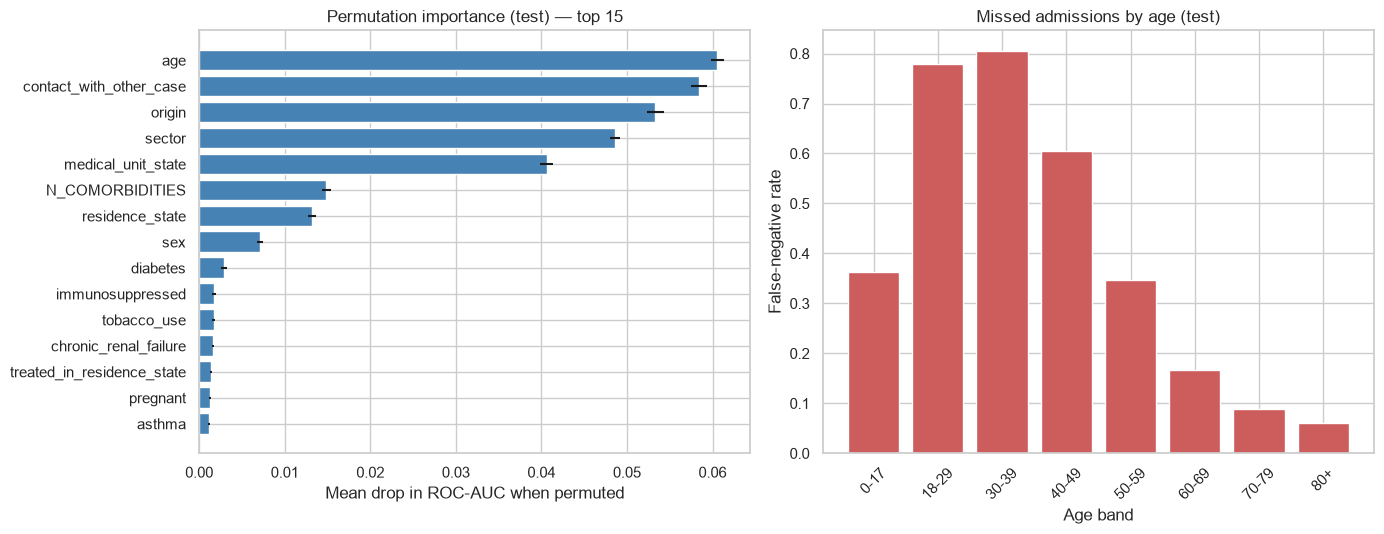

In [9]:
# ===== [V2 ADDED] Permutation importance + false-negative rate by age band (test). =====
from sklearn.inspection import permutation_importance

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# (left) Permutation feature importance: drop in ROC-AUC when each raw feature is shuffled.
# Subsampled for speed; raise n_pi / n_repeats for a more stable estimate.
rng = np.random.RandomState(RANDOM_STATE)
n_pi = min(50000, len(X_test))
sub = rng.choice(len(X_test), size=n_pi, replace=False)
pi = permutation_importance(best_model, X_test.iloc[sub], y_test.iloc[sub],
                            scoring='roc_auc', n_repeats=5,
                            random_state=RANDOM_STATE, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=X_test.columns).sort_values().tail(15)
axes[0].barh(imp.index, imp.values,
             xerr=pd.Series(pi.importances_std, index=X_test.columns).loc[imp.index],
             color='steelblue')
axes[0].set_xlabel("Mean drop in ROC-AUC when permuted")
axes[0].set_title("Permutation importance (test) — top 15")

# (right) False-negative rate by age band: share of truly-hospitalized patients sent home.
tmp = pd.DataFrame({'age': X_test['age'].to_numpy(),
                    'y_true': y_test.to_numpy(), 'y_pred': test_pred})
tmp['age_band'] = pd.cut(tmp['age'], bins=age_bins, labels=age_labels, right=False)
pos = tmp[tmp['y_true'] == 1]
fn_rate = pos.groupby('age_band', observed=True)['y_pred'].apply(lambda s: (s == 0).mean())
axes[1].bar(fn_rate.index.astype(str), fn_rate.values, color='indianred')
axes[1].set_xlabel("Age band"); axes[1].set_ylabel("False-negative rate")
axes[1].set_title("Missed admissions by age (test)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.show()


### Error analysis

We examine where the final model errs on the **test set**, sliced by age band, sex, comorbidity burden, and health sector, to distinguish systematic bias from genuine unpredictability. We report per-group error rate and, because false negatives are the clinically dangerous case, the group false-negative rate (share of truly-hospitalized patients predicted as outpatient).

In [10]:
err = X_test.copy()
err['y_true'] = y_test.values
err['y_pred'] = test_pred
err['age_band'] = pd.cut(err['age'], bins=age_bins, labels=age_labels, right=False)
err['n_comorb'] = err[comorbidity_cols].fillna(0).sum(axis=1).clip(upper=4).astype(int)


def group_report(col):
    def summarize(sub):
        pos = sub['y_true'] == 1
        false_neg = (pos & (sub['y_pred'] == 0)).sum()
        return pd.Series({
            'n': len(sub),
            'error_rate': 1 - (sub['y_true'] == sub['y_pred']).mean(),
            'false_neg_rate': false_neg / max(int(pos.sum()), 1),
        })
    return err.groupby(col, observed=True).apply(summarize, include_groups=False).round(3)


for col in ['age_band', 'sex', 'n_comorb', 'sector']:
    print(f"\n=== Error by {col} ===")
    print(group_report(col))


=== Error by age_band ===
                n  error_rate  false_neg_rate
age_band                                     
0-17       2532.0       0.192           0.363
18-29      8890.0       0.077           0.780
30-39     12608.0       0.102           0.806
40-49     11587.0       0.150           0.604
50-59      8442.0       0.194           0.346
60-69      4586.0       0.201           0.166
70-79      2299.0       0.197           0.088
80+        1243.0       0.188           0.061

=== Error by sex ===
              n  error_rate  false_neg_rate
sex                                        
Female  25629.0       0.125           0.453
Male    26558.0       0.159           0.349

=== Error by n_comorb ===
                n  error_rate  false_neg_rate
n_comorb                                     
0         29295.0       0.113           0.580
1         13508.0       0.157           0.387
2          6069.0       0.204           0.240
3          2328.0       0.217           0.156
4           

**Error-analysis takeaways.** Two distinct patterns emerge. **Overall error rate** peaks in the clinically ambiguous middle — age 50–59 (~27%) and 4+ comorbidities (~31%) — where the admission decision is genuinely a judgment call and hardest to predict. The **dangerous error (false negatives)** shows the opposite gradient: it is concentrated in **young, low-comorbidity** patients (age 18–29: ~82% of true admissions missed; 0 comorbidities: ~48%) and is very low for the elderly (70–79: ~7%). The model has learned the base rate — a young, otherwise-healthy patient who nonetheless requires admission is rare and atypical, so the model defaults them to *outpatient*. This is a **base-rate / limited-signal effect, not a correctable bug**: presentation-time features simply do not separate the rare severe young cases. Differences across `sector` (e.g. higher false-negative rates in small private/military units) more likely reflect **institutional admission thresholds and bed capacity** — plus very small sample sizes for minor sectors — than genuine model bias, i.e. a data/deployment limitation. The practical implication is the one flagged in the fairness note: a deployed model should **lower the decision threshold for younger patients** or defer to clinicians there, and must never be used to deny admission.

In [ ]:
import sklearn, matplotlib, seaborn, plotly, optuna

print("Library versions")
for m in [np, pd, sklearn, matplotlib, seaborn, plotly, optuna]:
    print(f"  {m.__name__}: {m.__version__}")

print(f"\nRANDOM_STATE = {RANDOM_STATE}")
print("Saved split indices: train_idx.npy, test_idx.npy")
print(f"Reload check: train={len(np.load('train_idx.npy')):,}, "
      f"test={len(np.load('test_idx.npy')):,}")